# Horizontal Pong — Multi-Agent Learning Curves

This notebook automatically loads all available training logs from `../artifacts/train_log_*.csv`
and compares learning dynamics across agents (up to 4+ agents if present).

It produces:
1. Smoothed reward learning curves.
2. Smoothed hits-per-episode curves (if `hits` exists).
3. Smoothed loss curves (`actor_loss`, `critic_loss`, `total_loss` when available).
4. Stability view (rolling reward std) and quick summary table.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# Load all available train logs
artifacts_dir = Path("../artifacts")
log_paths = sorted(artifacts_dir.glob("train_log_*.csv"))

if not log_paths:
    raise FileNotFoundError("No train logs found in ../artifacts (expected train_log_*.csv)")

logs = {}
for p in log_paths:
    agent_name = p.stem.replace("train_log_", "")
    df = pd.read_csv(p)
    if "episode" not in df.columns:
        df["episode"] = np.arange(1, len(df) + 1)
    logs[agent_name] = df

print("Loaded logs:")
for name, df in logs.items():
    print(f"- {name:20s} rows={len(df):5d} columns={list(df.columns)}")

WINDOW = 100

Loaded logs:
- actor_critic         rows= 1248 columns=['episode', 'reward', 'hits', 'length', 'critic_loss', 'actor_loss', 'entropy_loss', 'total_loss', 'grad_norm', 'lr']
- reinforce            rows= 6112 columns=['episode', 'reward', 'hits', 'length', 'actor_loss']
- reinforce_baseline   rows= 4671 columns=['episode', 'reward', 'hits', 'length', 'actor_loss']
- trpo                 rows= 1846 columns=['episode', 'reward', 'hits', 'length', 'surrogate_before', 'surrogate_after', 'kl', 'entropy', 'grad_norm']


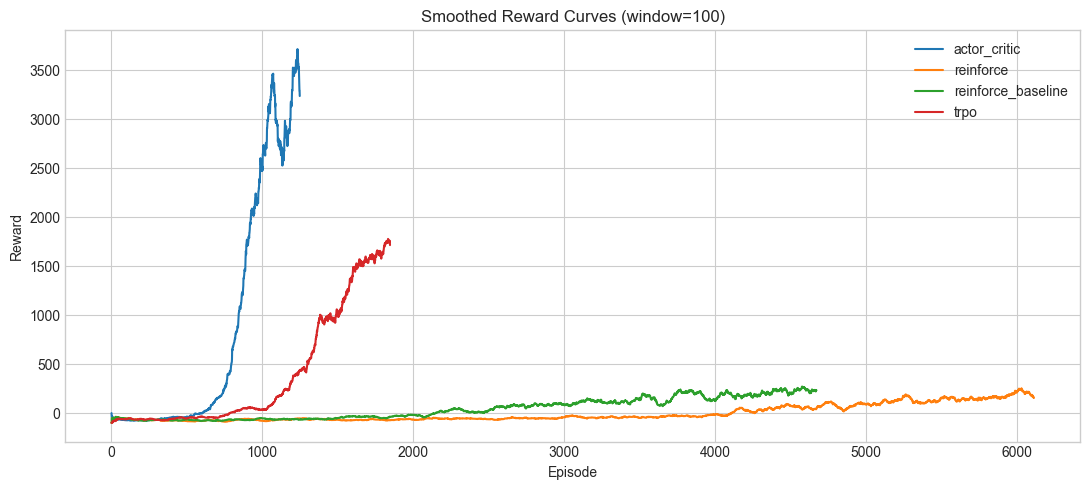

In [3]:
# Learning curves: reward (smoothed)
plt.figure(figsize=(11, 5))
for agent, df in logs.items():
    if "reward" not in df.columns:
        continue
    smooth = df["reward"].rolling(WINDOW, min_periods=1).mean()
    plt.plot(df["episode"], smooth, label=agent)

plt.title(f"Smoothed Reward Curves (window={WINDOW})")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.tight_layout()
plt.show()

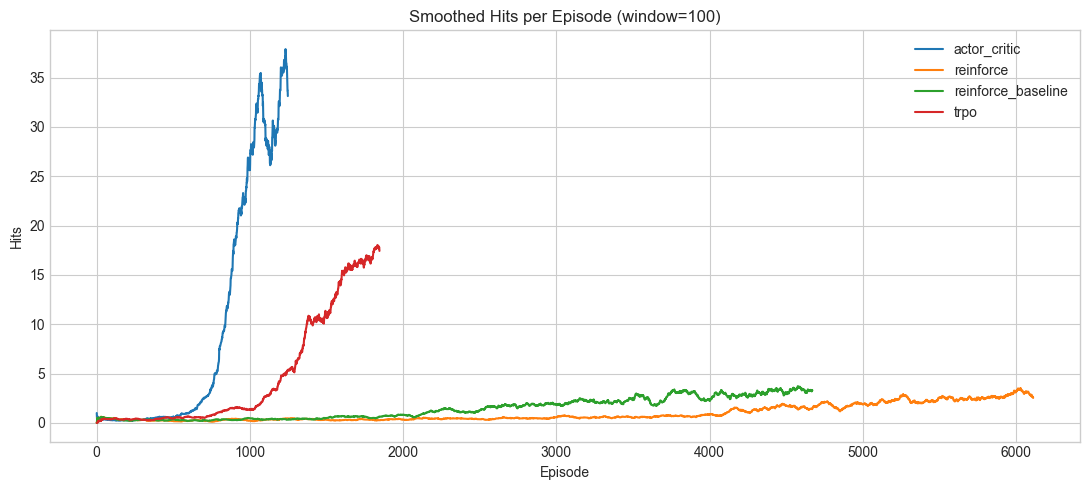

In [4]:
# Hits comparison (if available)
plt.figure(figsize=(11, 5))
plotted = False
for agent, df in logs.items():
    if "hits" not in df.columns:
        continue
    smooth = df["hits"].rolling(WINDOW, min_periods=1).mean()
    plt.plot(df["episode"], smooth, label=agent)
    plotted = True

if plotted:
    plt.title(f"Smoothed Hits per Episode (window={WINDOW})")
    plt.xlabel("Episode")
    plt.ylabel("Hits")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No 'hits' column found in loaded logs.")

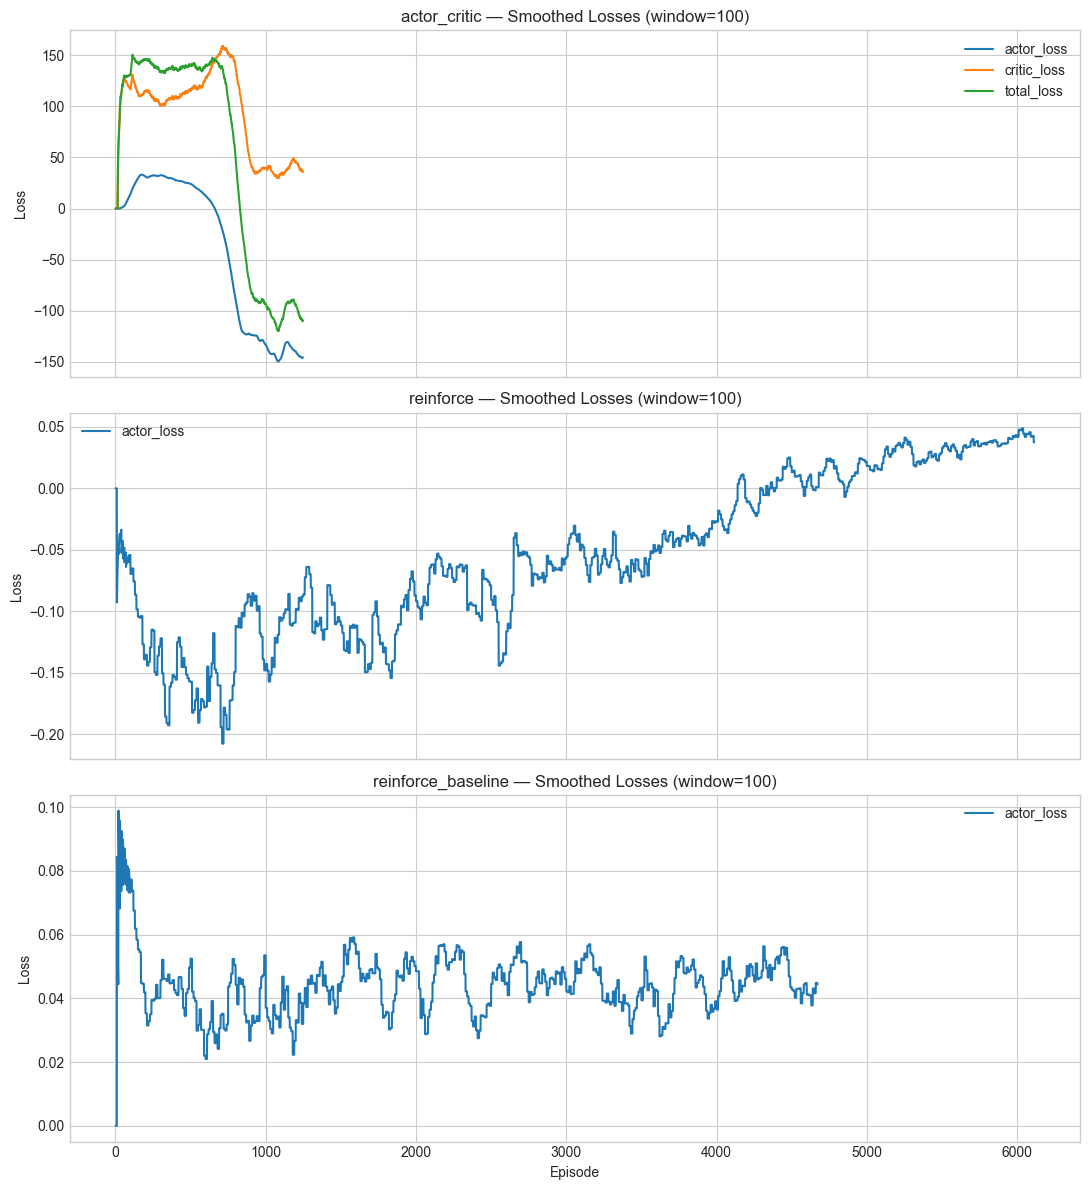

In [5]:
# Actor-Critic loss dynamics
loss_cols = ["actor_loss", "critic_loss", "total_loss"]
ac_df = logs.get("actor_critic")

if ac_df is not None:
    fig, ax = plt.subplots(figsize=(11, 5))
    for col in loss_cols:
        if col in ac_df.columns:
            smooth = ac_df[col].rolling(WINDOW, min_periods=1).mean()
            ax.plot(ac_df["episode"], smooth, label=col)
    ax.set_title(f"Actor-Critic — Smoothed Losses (window={WINDOW})")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No actor_critic log found.")

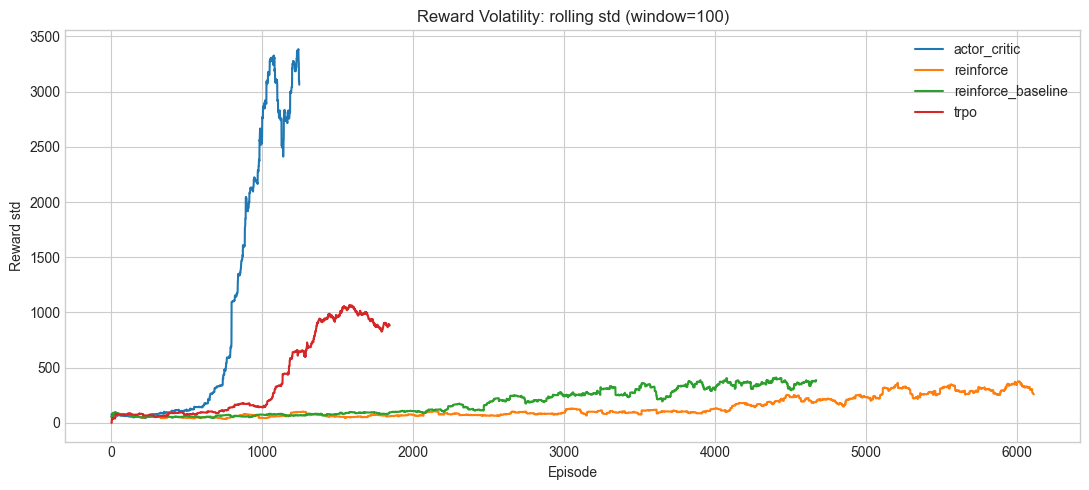

,agent,episodes,last100_reward_mean,last100_reward_std,last100_hits_mean,last100_hits_std,last100_actor_loss_mean,last100_actor_loss_std,last100_critic_loss_mean,last100_critic_loss_std,last100_total_loss_mean,last100_total_loss_std,last100_grad_norm_mean,last100_grad_norm_std
0,actor_critic,1248,3237.0,3046.987200,33.13,30.251167,-145.808617,19.352173,36.257498,41.986833,-109.576232,40.161087,789.135987,790.811476
1,reinforce,6112,155.0,257.827462,2.54,2.586194,0.037405,0.117308,NaN,NaN,NaN,NaN,NaN,NaN
2,reinforce_baseline,4671,232.0,384.416441,3.29,3.790237,0.044389,0.146416,NaN,NaN,NaN,NaN,NaN,NaN
3,trpo,1846,1715.0,880.724134,17.43,8.544302,NaN,NaN,NaN,NaN,NaN,NaN,0.005365,0.017018


In [6]:
# Stability + summary table
# 1) Reward stability via rolling std
plt.figure(figsize=(11, 5))
plotted = False
for agent, df in logs.items():
    if "reward" not in df.columns:
        continue
    reward_std = df["reward"].rolling(WINDOW, min_periods=5).std()
    plt.plot(df["episode"], reward_std, label=agent)
    plotted = True

if plotted:
    plt.title(f"Reward Volatility: rolling std (window={WINDOW})")
    plt.xlabel("Episode")
    plt.ylabel("Reward std")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No 'reward' column found in loaded logs.")

# 2) Quick comparison table using last WINDOW episodes
summary_rows = []
for agent, df in logs.items():
    row = {"agent": agent, "episodes": len(df)}

    for col in ["reward", "hits", "actor_loss", "critic_loss", "total_loss", "grad_norm"]:
        if col in df.columns and len(df) > 0:
            row[f"last{WINDOW}_{col}_mean"] = float(df[col].tail(WINDOW).mean())
            row[f"last{WINDOW}_{col}_std"] = float(df[col].tail(WINDOW).std(ddof=0))
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values("agent").reset_index(drop=True)
summary_df